In [56]:
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [57]:
cmap = sns.color_palette("Blues", as_cmap=True)

In [58]:
# Set the input directory
input_dir = Path("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/ephemeral/IMC_output_folder_11_06_2026/")
output_dir = Path("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/all_IMC/out")

# All Cells

In [59]:
df = pd.read_csv(input_dir / "03_Image_and_Cell_level_QC/figure_data/heatmap_all_cells.tsv", sep="\t")

In [60]:
# Convert long -> wide
mat = df.pivot(
    index="marker",
    columns="cell_id",
    values="value"
)

In [61]:
mat.max().max()

np.float64(10.0155164835411)

/Users/sarapatti/miniforge3/envs/imc/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/sarapatti/miniforge3/envs/imc/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


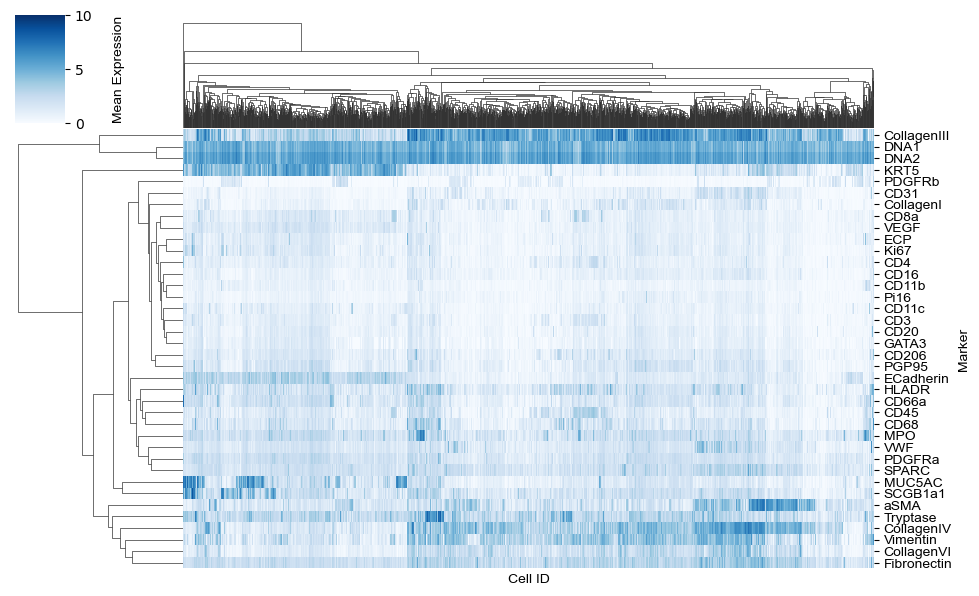

In [62]:
g = sns.clustermap(
    mat,
    cmap=cmap,
    vmin=0,
    vmax=10,
    figsize=(10, 6),
    xticklabels=False,
    yticklabels=True

)

# Set y-axis tick labels font
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontname="Arial",
    fontsize=10
)

# Relabel x-axis
g.ax_heatmap.set_xlabel(
    "Cell ID",
    fontname="Arial",
    fontsize=10
)

# Optional: relabel y-axis
g.ax_heatmap.set_ylabel(
    "Marker",
    fontname="Arial",
    fontsize=10
)

# Add colorbar label
g.ax_cbar.set_ylabel(
    "Mean Expression",
    rotation=90,
    labelpad=15,
    fontname="Arial",
    fontsize=10,
)


# Save the figure
g.savefig(output_dir / "cell_ID_heatmap.pdf", dpi=300, bbox_inches="tight")

# Mean expression per sample ID

In [63]:
df = pd.read_csv(input_dir / "03_Image_and_Cell_level_QC/figure_data/heatmap_mean_expression_per_image.tsv", sep="\t")

In [64]:
df["value"].max()

np.float64(6.89505541361985)

In [65]:
# Convert long -> wide
mat = df.pivot(
    index="marker",
    columns="image_id",
    values="value"
)

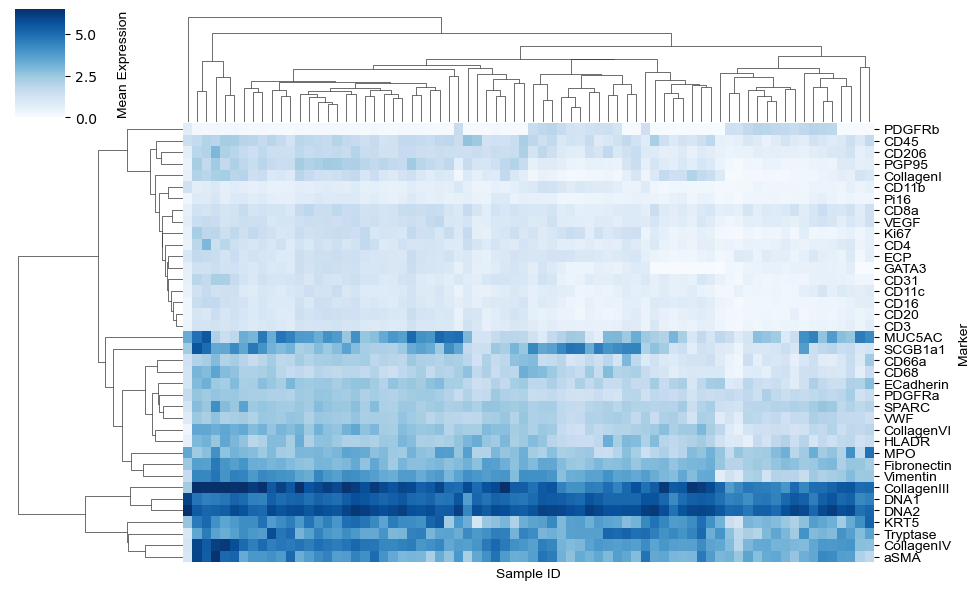

In [66]:
g = sns.clustermap(
    mat,
    cmap=cmap,
    vmin=0,
    vmax=6.5,
    figsize=(10, 6),
    xticklabels=False,
    yticklabels=True

)

# Set y-axis tick labels font
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontname="Arial",
    fontsize=10
)

# Relabel x-axis
g.ax_heatmap.set_xlabel(
    "Sample ID",
    fontname="Arial",
    fontsize=10
)

# Optional: relabel y-axis
g.ax_heatmap.set_ylabel(
    "Marker",
    fontname="Arial",
    fontsize=10
)

# Add colorbar label
g.ax_cbar.set_ylabel(
    "Mean Expression",
    rotation=90,
    labelpad=15,
    fontname="Arial",
    fontsize=10,
)


# Save the figure
g.savefig("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/all_IMC/out/sample_ID_heatmap.pdf", dpi=300, bbox_inches="tight")

# Cell density

In [67]:
sample_ID = pd.read_excel("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/all_IMC/docs/IMC_slideID_sampleID.xlsx")

In [68]:
df = pd.read_csv(input_dir / "03_Image_and_Cell_level_QC/figure_data/cell_density_per_mm2.tsv", sep="\t")

In [69]:
# mapping table (your first dataframe)
# columns: sample_ID, Slide_ID
mapping_df = sample_ID  # rename if needed

# build lookup: Slide_ID -> sample_ID
slide_to_sample = mapping_df.set_index("Slide_ID")["sample_ID"].to_dict()

# replace values in df, keep original if no match
df["slide_ID"] = df["slide_ID"].map(slide_to_sample).fillna(df["slide_ID"])

In [70]:
# Remove row by name
df = df[df['slide_ID'] != 'HA0157']

In [71]:
# Sort values by cells_per_mm2
df.sort_values(by="cells_per_mm2", ascending=True, inplace=True)

/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_29299/1175863717.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_yticklabels(
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_29299/1175863717.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(


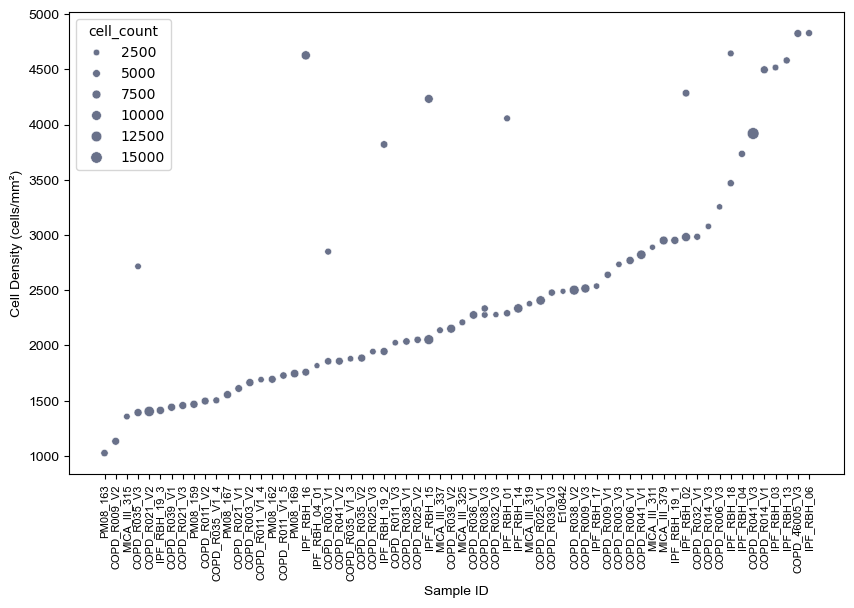

In [72]:
plt.figure(figsize=(10, 6))

g = sns.scatterplot(
    data=df,
    x='slide_ID',
    y='cells_per_mm2',
    size="cell_count",
    color='#69718a'
    )


# Set y-axis tick labels font
g.set_yticklabels(
    g.get_yticklabels(),
    fontname="Arial",
    fontsize=10,
)

# Relabel x-axis
g.set_xlabel(
    "Sample ID",
    fontname="Arial",
    fontsize=10,
)

g.set_xticklabels(
    g.get_xticklabels(),
    rotation=90,
    ha='center',
    fontname="Arial",
    fontsize=8
)

# Optional: relabel y-axis
g.set_ylabel(
    "Cell Density (cells/mm²)",
    fontname="Arial",
    fontsize=10
)

# Save the figure
plt.savefig(output_dir / "cell_density.pdf", dpi=300, bbox_inches="tight")

# Cell Density % area covered

In [73]:
df = pd.read_csv(input_dir / "03_Image_and_Cell_level_QC/figure_data/cell_density.tsv", sep="\t")

In [74]:
# mapping table (your first dataframe)
# columns: sample_ID, Slide_ID
mapping_df = sample_ID  # rename if needed

# build lookup: Slide_ID -> sample_ID
slide_to_sample = mapping_df.set_index("Slide_ID")["sample_ID"].to_dict()

# replace values in df, keep original if no match
df["slide_ID"] = df["slide_ID"].map(slide_to_sample).fillna(df["slide_ID"])

In [75]:
# Remove row by name
df = df[df['slide_ID'] != 'HA0157']

In [76]:
# Sort by cell density
df.sort_values(by="covered_area", ascending=True, inplace=True)

/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_29299/4133443755.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_29299/4133443755.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_yticklabels(


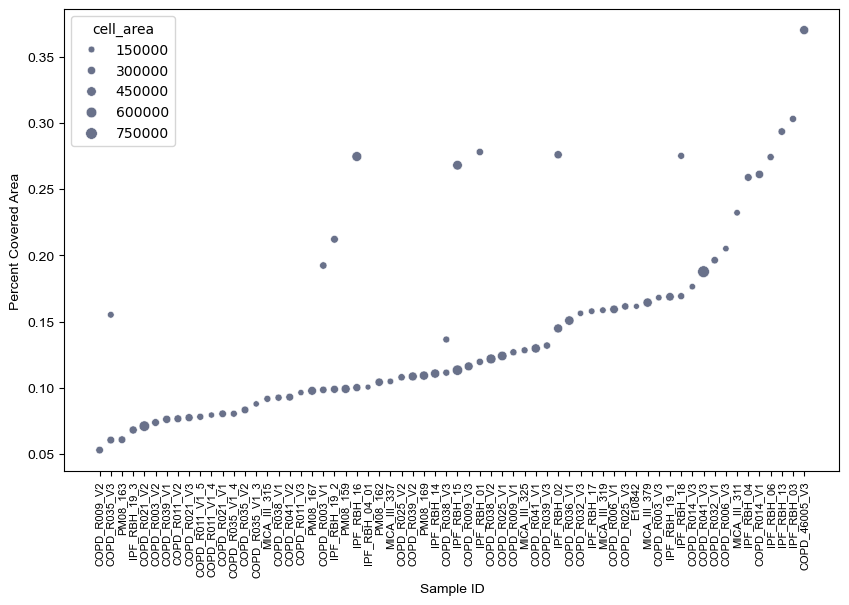

In [77]:
plt.figure(figsize=(10, 6))

g = sns.scatterplot(
    data=df,
    x='slide_ID',
    y='covered_area',
    size="cell_area",
    color='#69718a'
    )


# Relabel x-axis
g.set_xlabel(
    "Sample ID",
    fontname="Arial",
    fontsize=10,
)

g.set_xticklabels(
    g.get_xticklabels(),
    rotation=90,
    ha='center',
    fontname="Arial",
    fontsize=8
)

# Set y-axis tick labels font
g.set_yticklabels(
    g.get_yticklabels(),
    fontname="Arial",
    fontsize=10,
)

# Optional: relabel y-axis
g.set_ylabel(
    "Percent Covered Area",
    fontname="Arial",
    fontsize=10
)

# Save the figure
plt.savefig(output_dir / "percent_covered_area.pdf", dpi=300, bbox_inches="tight")

# Signal to noise ratio

## Cell level

In [78]:
df = pd.read_csv(input_dir / "03_Image_and_Cell_level_QC/figure_data/SNR_cell_level.tsv", sep="\t")

In [79]:
df["ps_log2"] = np.log2(df["ps"] + 1)

In [80]:
df.sort_values(by='log2_snr', ascending=True, inplace=True)

/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_29299/58309013.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_yticklabels(


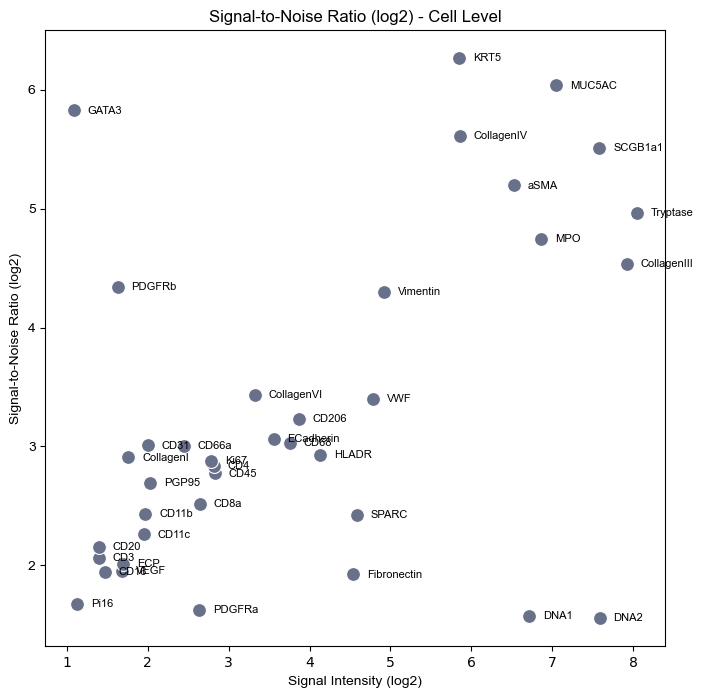

In [81]:
plt.figure(figsize=(8, 8))

g = sns.scatterplot(
    data=df,
    x="ps_log2",
    y="log2_snr",
    color="#69718a",
    s=100
)

# g.set_xticklabels(
#     g.get_xticklabels(),
#     rotation=90,
#     ha='center',
#     fontname="Arial",
#     fontsize=8
# )

for _, row in df.iterrows():
    g.annotate(
        row["marker"],              # text to display
        (row["ps_log2"], row["log2_snr"]),  # point coordinates
        xytext=(10, 0),             # offset in points
        textcoords="offset points",
        fontsize=8,
        fontname="Arial",
        ha="left",
        va="center",
    )

# Set y-axis tick labels font
g.set_yticklabels(
    g.get_yticklabels(),
    fontname="Arial",
    fontsize=10,
)

# Optional: relabel y-axis
g.set_ylabel(
    "Signal-to-Noise Ratio (log2)", # (Pixel Adjusted)
    fontname="Arial",
    fontsize=10
)

# Relabel x-axis
g.set_xlabel(
    "Signal Intensity (log2)",
    fontname="Arial",
    fontsize=10,
)


g.set_title(
    "Signal-to-Noise Ratio (log2) - Cell Level", 
    fontname="Arial",
    fontsize=12
)

plt.savefig(output_dir / "SNR_cell_level.pdf", dpi=300, bbox_inches="tight")

## Pixel level - non adjusted

In [82]:
df = pd.read_csv(input_dir / "03_Image_and_Cell_level_QC/figure_data/SNR_pixel_level.tsv", sep="\t")

/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_29299/2972312529.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(
/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_29299/2972312529.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_yticklabels(


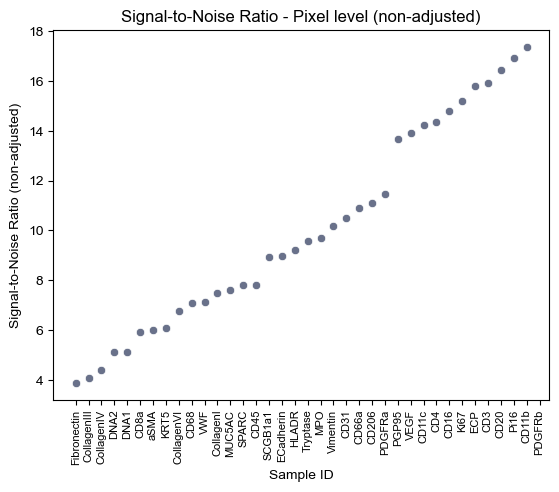

In [83]:
df.sort_values(by='snr', ascending=True, inplace=True)

g = sns.scatterplot(
    data=df,
    x="marker",
    y="snr",
    color="#69718a"
)

g.set_xticklabels(
    g.get_xticklabels(),
    rotation=90,
    ha='center',
    fontname="Arial",
    fontsize=8
)

# Set y-axis tick labels font
g.set_yticklabels(
    g.get_yticklabels(),
    fontname="Arial",
    fontsize=10,
)

# Optional: relabel y-axis
g.set_ylabel(
    "Signal-to-Noise Ratio (non-adjusted)",
    fontname="Arial",
    fontsize=10
)

# Relabel x-axis
g.set_xlabel(
    "Sample ID",
    fontname="Arial",
    fontsize=10,
)

g.set_title(
    "Signal-to-Noise Ratio - Pixel level (non-adjusted)",
    fontname="Arial",
    fontsize=12
)

plt.savefig(output_dir / "SNR_pixel_level_non_adjusted.pdf", dpi=300, bbox_inches="tight")

## Pixel level - adjusted

In [84]:
df = pd.read_csv(input_dir / "03_Image_and_Cell_level_QC/figure_data/SNR_pixel_adjusted.tsv", sep="\t")

In [85]:
df.sort_values(by='snr', ascending=True, inplace=True)

/var/folders/yq/6fgvx0fj0cs57zmqydzbhbfh0000gn/T/ipykernel_29299/1932777198.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_yticklabels(


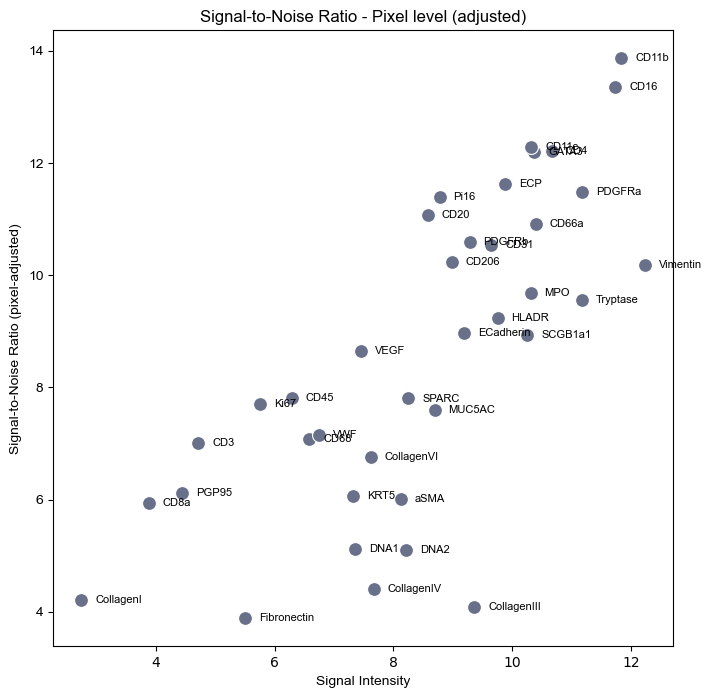

In [86]:
plt.figure(figsize=(8, 8))

g = sns.scatterplot(
    data=df,
    x="ps",
    y="snr",
    color="#69718a",
    s=100
)

for _, row in df.iterrows():
    g.annotate(
        row["marker"],              # text to display
        (row["ps"], row["snr"]),  # point coordinates
        xytext=(10, 0),             # offset in points
        textcoords="offset points",
        fontsize=8,
        fontname="Arial",
        ha="left",
        va="center",
    )

# g.set_xticklabels(
#     g.get_xticklabels(),
#     rotation=90,
#     ha='center',
#     fontname="Arial",
#     fontsize=8
# )

# Set y-axis tick labels font
g.set_yticklabels(
    g.get_yticklabels(),
    fontname="Arial",
    fontsize=10,
)

# Optional: relabel y-axis
g.set_ylabel(
    "Signal-to-Noise Ratio (pixel-adjusted)",
    fontname="Arial",
    fontsize=10
)

# Relabel x-axis
g.set_xlabel(
    "Signal Intensity",
    fontname="Arial",
    fontsize=10,
)

g.set_title(
    "Signal-to-Noise Ratio - Pixel level (adjusted)",
    fontname="Arial",
    fontsize=12
)

plt.savefig(output_dir / "SNR_pixel_level_adjusted.pdf", dpi=300, bbox_inches="tight")